# Bank Customer Churn Prediction
## Exploratory Data Analysis (EDA)

This notebook performs structured exploratory analysis on the Bank Customer Churn dataset.

Goals:
1. Understand dataset structure
2. Analyze feature distributions
3. Identify class imbalance
4. Detect potential data quality issues
5. Generate business-relevant insights before modeling

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [3]:
# Load dataset
df = pd.read_csv("../data/raw/bank_customer_churn_dataset.csv")

# Preview first rows
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Dataset Structure

In [4]:
# Number of rows and columns
df.shape

(10000, 12)

In [5]:
# Column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


## Target Variable Analysis


The target variable is `churn`.

- 1 → Customer left the bank
- 0 → Customer stayed

We analyze class distribution to understand imbalance and modeling implications.

In [6]:
# Count of each class
df["churn"].value_counts()

0    7963
1    2037
Name: churn, dtype: int64

In [7]:
# Percentage distribution
df["churn"].value_counts(normalize=True) * 100

0    79.63
1    20.37
Name: churn, dtype: float64

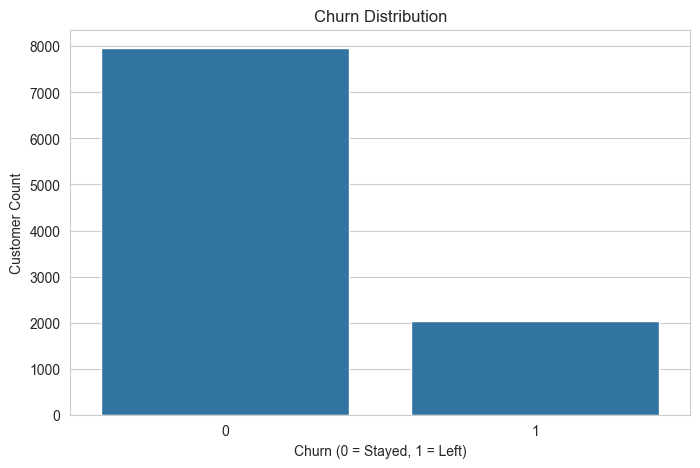

In [9]:
# Visualisation
sns.countplot(x="churn", data=df)
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = Stayed, 1 = Left)")
plt.ylabel("Customer Count")
plt.show()

### Observations


1. The dataset is moderately imbalanced.
2. Approximately 20% of customers have churned.
3. Class imbalance must be considered during model evaluation.
4. Accuracy alone may not be sufficient; precision, recall, and ROC-AUC will be important.

In [10]:
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

## Removing Identifier Column

`customer_id` is a unique identifier and does not contribute to churn prediction.
Removing it from the dataset.

In [11]:
# Drop customer_id
df = df.drop(columns=["customer_id"])

df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
df.columns

Index(['credit_score', 'country', 'gender', 'age', 'tenure', 'balance',
       'products_number', 'credit_card', 'active_member', 'estimated_salary',
       'churn'],
      dtype='object')

## Missing Value Check


We verify whether the dataset contains missing values that require cleaning before modeling.

In [13]:
# Check missing values
df.isnull().sum()

credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

### Observation

The dataset does not contain missing values.
No imputation is required.

## Data Type Inspection

We confirm numerical and categorical feature types before preprocessing.

In [14]:
df.dtypes

credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

## Numerical Feature Analysis

We examine distributions of numerical variables to:

- Understand customer characteristics
- Detect skewness or outliers
- Identify features that may influence churn

In [15]:
# Select numerical columns (excluding target)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Remove target column
num_cols.remove("churn")

num_cols

['credit_score',
 'age',
 'tenure',
 'balance',
 'products_number',
 'credit_card',
 'active_member',
 'estimated_salary']

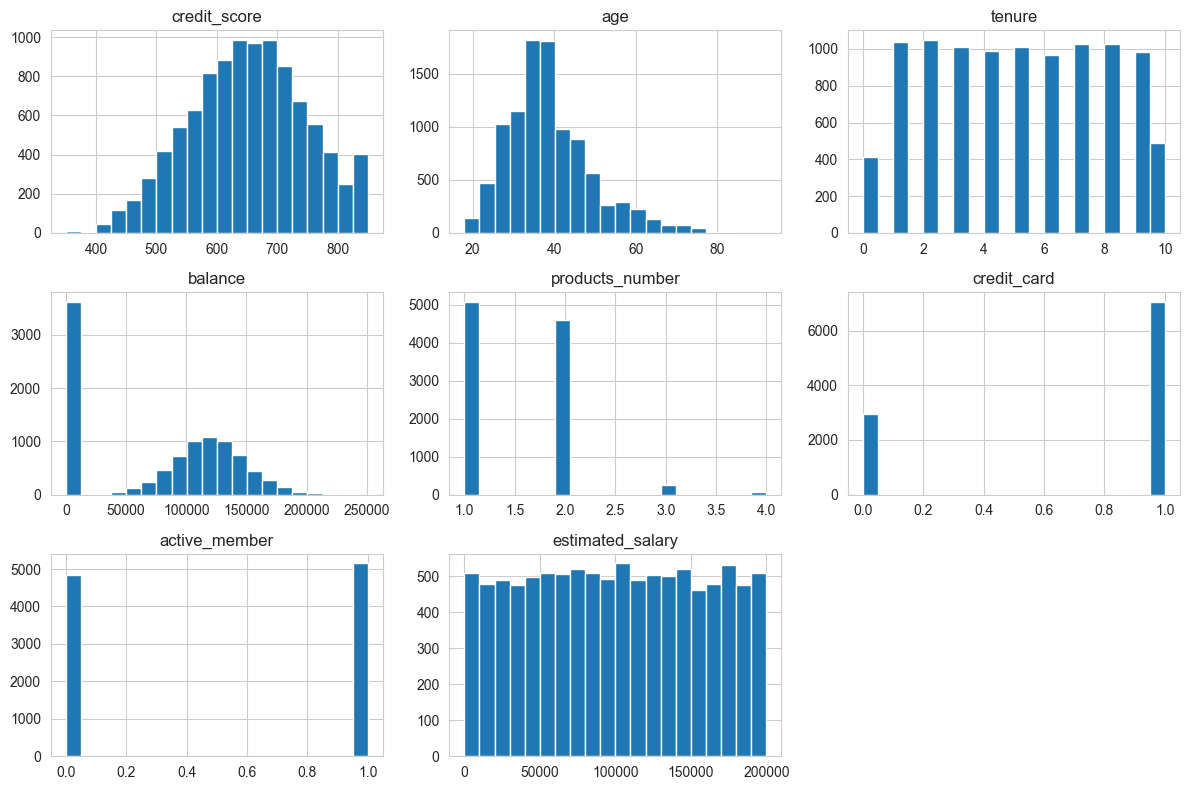

In [16]:
# Plot distributions
df[num_cols].hist(bins=20, figsize=(12, 8))
plt.tight_layout()
plt.show()

### Observations from Numerical Distributions

- **Credit Score:** Roughly normally distributed, centered around the mid-600s. No extreme outliers observed.

- **Age:** Slight right skew. Majority of customers fall between 30–50 years. A smaller group exists above 60.

- **Tenure:** Fairly uniform distribution from 0 to 10 years. No strong skew.

- **Balance:** Large spike at zero balance, indicating many customers have no account balance. Remaining values are moderately spread with slight right skew.

- **Products Number:** Most customers have 1 or 2 products. Very few customers hold 3 or 4 products.

- **Credit Card:** Majority of customers own a credit card.

- **Active Member:** Distribution is relatively balanced between active and inactive customers.

- **Estimated Salary:** Appears uniformly distributed across the full salary range. No obvious clustering.

These distributions help identify potential predictive signals (e.g., balance concentration at zero, product usage patterns).

## Numerical Features vs Churn

We analyze how numerical variables differ between customers who churned and those who stayed.

This helps identify strong predictive signals.

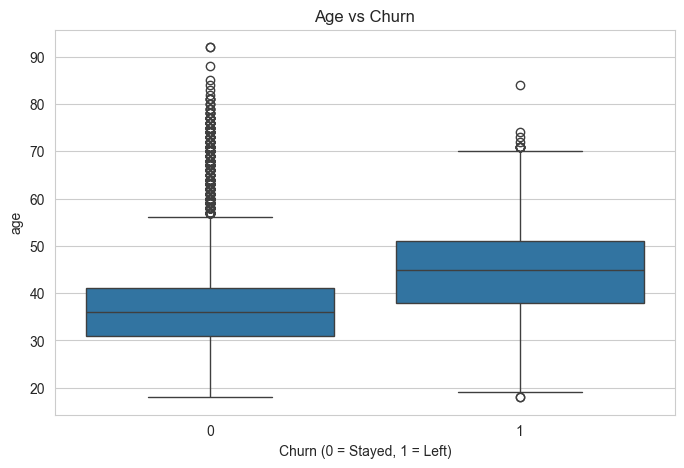

In [17]:
sns.boxplot(x="churn", y="age", data=df)
plt.title("Age vs Churn")
plt.xlabel("Churn (0 = Stayed, 1 = Left)")
plt.show()

In [ ]:
sns.boxplot(x="churn", y="balance", data=df)
plt.title("Balance vs Churn")
plt.xlabel("Churn (0 = Stayed, 1 = Left)")
plt.show()